# 🚢 YOLO Ship Segmentation Training on SSDD Dataset

This notebook trains YOLOv8/YOLOv11 segmentation models for ship instance segmentation using the preprocessed SSDD dataset.

**Dataset:** SSDD (SAR Ship Detection Dataset) - 1160 images with polygon annotations  
**Task:** Instance Segmentation (Ship Segmentation)  
**Hardware:** Google Colab T4 GPU  
**Models:** YOLOv8n-seg, YOLOv8s-seg, YOLOv11n-seg, YOLOv11s-seg

---

## 🔧 Setup and Installation

In [ ]:
# Check GPU availability
!nvidia-smi

# Install required packages
!pip install ultralytics roboflow supervision
!pip install -q wandb

# Import libraries
import torch
import os
import yaml
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
import cv2
from google.colab import files
import zipfile

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Thu Oct 16 17:16:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 📁 Upload Preprocessed Dataset

Upload your `SSDD_coco_preprocessed.zip` file containing the preprocessed images and YOLO format annotations.

In [ ]:
from google.colab import drive
import zipfile
from pathlib import Path
import os

# 🔹 Mount Google Drive
drive.mount('/content/drive')

# 🔹 Automatically locate your ZIP file inside MyDrive
base_path = Path('/content/drive/MyDrive')
dataset_zip = None

for file in base_path.glob('**/*.zip'):
    if "SSDD_coco_preprocessed" in file.name:
        dataset_zip = file
        break

if dataset_zip is None:
    print("❌ Could not find 'SSDD_coco_preprocessed.zip' in MyDrive.")
else:
    print(f"Found ZIP file: {dataset_zip}")
    extract_path = "/content/"

    # 🔹 Extract dataset
    try:
        print(f"Extracting {dataset_zip.name}...")
        with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extracted successfully!")

        # 🔹 Verify dataset structure
        dataset_path = Path(extract_path) / Path(dataset_zip).stem
        if dataset_path.exists():
            print(f"\n📊 Dataset structure:")
            for split in ['train', 'val', 'test']:
                images_dir = dataset_path / split / 'images'
                labels_dir = dataset_path / split / 'labels'
                if images_dir.exists() and labels_dir.exists():
                    img_count = len(list(images_dir.glob('*.jpg')))
                    label_count = len(list(labels_dir.glob('*.txt')))
                    print(f"  {split}: {img_count} images, {label_count} labels")
        else:
            print("⚠️ Extraction completed but dataset folder not found. Check ZIP structure.")

    except zipfile.BadZipFile:
        print("❌ The ZIP file appears to be corrupted. Try re-uploading it to Google Drive.")


Mounted at /content/drive
Found ZIP file: /content/drive/MyDrive/SSDD_coco_preprocessed.zip
Extracting SSDD_coco_preprocessed.zip...
✅ Dataset extracted successfully!

📊 Dataset structure:
  train: 928 images, 928 labels
  val: 116 images, 116 labels
  test: 116 images, 116 labels


## 📊 Dataset Analysis

In [ ]:
# Analyze dataset
def analyze_dataset(dataset_path):
    stats = {'train': {}, 'val': {}, 'test': {}}

    for split in ['train', 'val', 'test']:
        images_dir = dataset_path / split / 'images'
        labels_dir = dataset_path / split / 'labels'

        if not images_dir.exists():
            continue

        # Count files
        image_files = list(images_dir.glob('*.jpg'))
        label_files = list(labels_dir.glob('*.txt'))

        stats[split]['images'] = len(image_files)
        stats[split]['labels'] = len(label_files)

        # Analyze image sizes
        if image_files:
            sample_img = cv2.imread(str(image_files[0]))
            stats[split]['image_size'] = sample_img.shape[:2] if sample_img is not None else None

        # Count objects
        total_objects = 0
        for label_file in label_files:
            try:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                    total_objects += len([line for line in lines if line.strip()])
            except:
                pass

        stats[split]['total_objects'] = total_objects
        stats[split]['avg_objects_per_image'] = total_objects / len(image_files) if image_files else 0

    return stats

# Analyze the dataset
dataset_stats = analyze_dataset(dataset_path)

print("📊 Dataset Statistics:")
print("=" * 50)
total_images = 0
total_objects = 0

for split, data in dataset_stats.items():
    if data:
        print(f"\n{split.upper()}:")
        print(f"  Images: {data['images']}")
        print(f"  Labels: {data['labels']}")
        print(f"  Total ships: {data['total_objects']}")
        print(f"  Avg ships/image: {data['avg_objects_per_image']:.2f}")
        if data['image_size']:
            print(f"  Image size: {data['image_size']}")

        total_images += data['images']
        total_objects += data['total_objects']

print(f"\n📈 TOTAL DATASET:")
print(f"  Total images: {total_images}")
print(f"  Total ships: {total_objects}")
print(f"  Average ships per image: {total_objects/total_images:.2f}")

📊 Dataset Statistics:

TRAIN:
  Images: 928
  Labels: 928
  Total ships: 928
  Avg ships/image: 1.00
  Image size: (345, 500)

VAL:
  Images: 116
  Labels: 116
  Total ships: 116
  Avg ships/image: 1.00
  Image size: (313, 497)

TEST:
  Images: 116
  Labels: 116
  Total ships: 116
  Avg ships/image: 1.00
  Image size: (277, 409)

📈 TOTAL DATASET:
  Total images: 1160
  Total ships: 1160
  Average ships per image: 1.00


## 👁️ Visualize Dataset Samples

🖼️ Training Samples (segmentation masks - green fill, red outline):


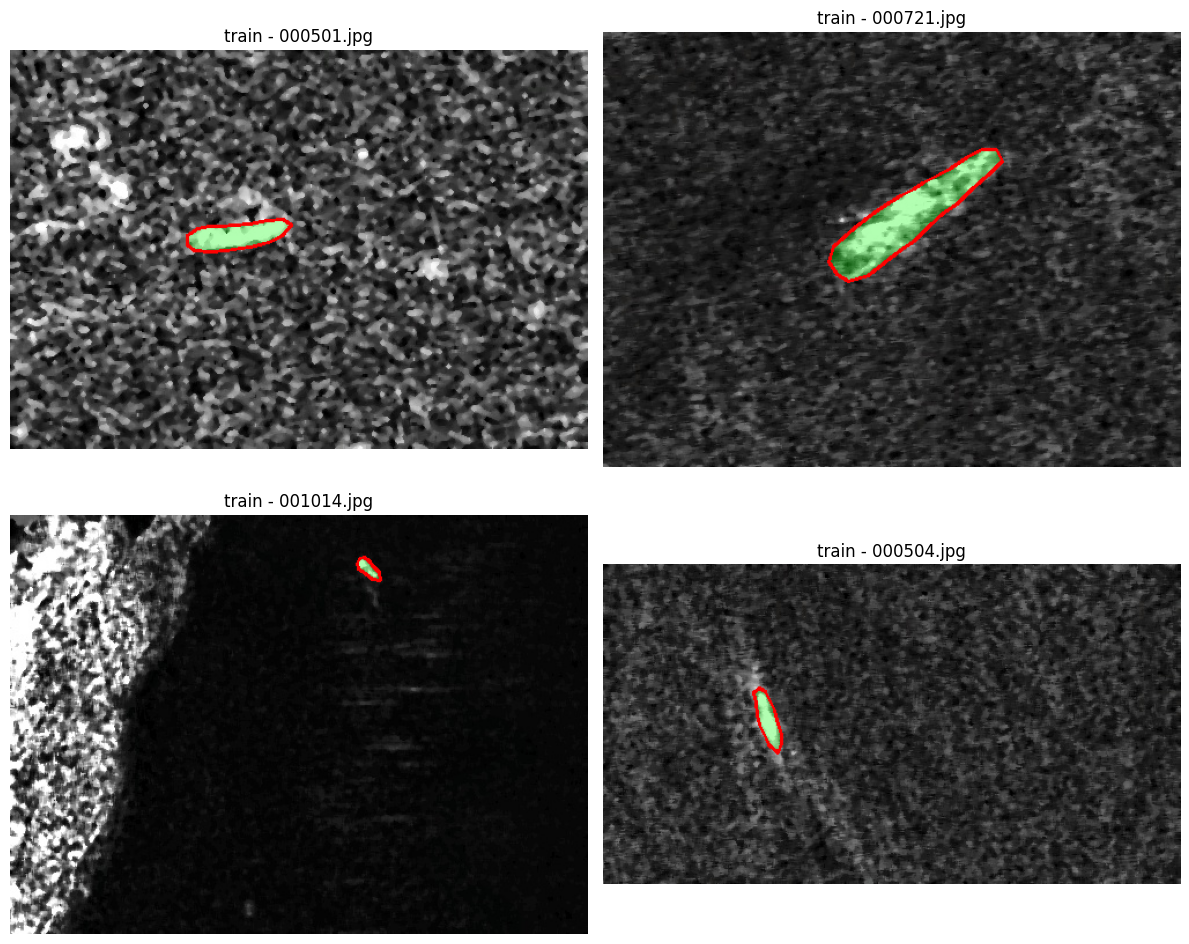

In [ ]:
def visualize_samples(dataset_path, split='train', num_samples=4):
    images_dir = dataset_path / split / 'images'
    labels_dir = dataset_path / split / 'labels'

    image_files = list(images_dir.glob('*.jpg'))[:num_samples]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(image_files):
        if i >= num_samples:
            break

        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Load corresponding label
        label_path = labels_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()

            # Draw segmentation annotations
            for line in lines:
                if line.strip():
                    parts = line.strip().split()
                    if len(parts) > 2:
                        # Convert normalized coordinates back to pixel coordinates
                        coords = [float(x) for x in parts[1:]]
                        points = []
                        for j in range(0, len(coords), 2):
                            x = int(coords[j] * w)
                            y = int(coords[j+1] * h)
                            points.append([x, y])

                        # Draw filled polygon for segmentation
                        points = np.array(points, dtype=np.int32)
                        # Draw filled polygon with transparency
                        overlay = img.copy()
                        cv2.fillPoly(overlay, [points], (0, 255, 0))
                        cv2.addWeighted(overlay, 0.3, img, 0.7, 0, img)
                        # Draw polygon outline
                        cv2.polylines(img, [points], True, (255, 0, 0), 2)

        axes[i].imshow(img)
        axes[i].set_title(f"{split} - {img_path.name}")
        axes[i].axis('off')

    # Hide unused subplots
    for i in range(len(image_files), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize training samples
print("🖼️ Training Samples (segmentation masks - green fill, red outline):")
visualize_samples(dataset_path, 'train', 4)

## ⚙️ Model Configuration

In [ ]:
# Training configuration for segmentation
TRAINING_CONFIG = {
    'model_options': {
        'yolov8n-seg': 'yolov8n-seg.pt',
        'yolov8s-seg': 'yolov8s-seg.pt',
        'yolov11n-seg': 'yolo11n-seg.pt',
        'yolov11s-seg': 'yolo11s-seg.pt'
    },
    'epochs': 200,
    'batch_size': 12,
    'imgsz': 640,
    'patience': 40,
    'save_period': 25,
    'workers': 2,
    'device': 0,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.1,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 5,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'hsv_h': 0.01,
    'hsv_s': 0.3,
    'hsv_v': 0.2,
    'degrees': 5.0,
    'translate': 0.1,
    'scale': 0.3,
    'shear': 2.0,
    'perspective': 0.0001,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 0.8,
    'mixup': 0.1,
    'copy_paste': 0.1,
    'dropout': 0.1,
    'label_smoothing': 0.05
}

SELECTED_MODEL = 'yolov8s-seg'

print(f"🎯 Selected Model: {SELECTED_MODEL}")
print(f"📊 Training Configuration:")
print(f"  Epochs: {TRAINING_CONFIG['epochs']}")
print(f"  Batch Size: {TRAINING_CONFIG['batch_size']}")
print(f"  Image Size: {TRAINING_CONFIG['imgsz']}")
print(f"  Learning Rate: {TRAINING_CONFIG['lr0']}")
print(f"  Optimizer: {TRAINING_CONFIG['optimizer']}")

🎯 Selected Model: yolov8s-seg
📊 Training Configuration:
  Epochs: 200
  Batch Size: 12
  Image Size: 640
  Learning Rate: 0.001
  Optimizer: AdamW


## 🚀 Model Training

In [ ]:
from ultralytics import YOLO
import time

# Initialize segmentation model
model_path = TRAINING_CONFIG['model_options'][SELECTED_MODEL]
model = YOLO(model_path)

print(f"🤖 Loaded {SELECTED_MODEL} segmentation model")
print(f"📁 Dataset path: {dataset_path}")

# Create dataset.yaml for segmentation
dataset_yaml = dataset_path / 'dataset.yaml'
if not dataset_yaml.exists():
    yaml_content = f"""path: {dataset_path}
train: train/images
val: val/images
test: test/images

names:
  0: ship

nc: 1
task: segment
"""
    with open(dataset_yaml, 'w') as f:
        f.write(yaml_content)
    print("✅ Created dataset.yaml for segmentation")

# Training parameters
train_params = {
    'data': str(dataset_yaml),
    'epochs': TRAINING_CONFIG['epochs'],
    'batch': TRAINING_CONFIG['batch_size'],
    'imgsz': TRAINING_CONFIG['imgsz'],
    'patience': TRAINING_CONFIG['patience'],
    'save_period': TRAINING_CONFIG['save_period'],
    'workers': TRAINING_CONFIG['workers'],
    'device': TRAINING_CONFIG['device'],
    'project': '/content/runs/segment',
    'name': f'{SELECTED_MODEL}_ship_segmentation',
    'exist_ok': True,
    'pretrained': True,
    'verbose': True,
    'seed': 42,
    'optimizer': TRAINING_CONFIG['optimizer'],
    'lr0': TRAINING_CONFIG['lr0'],
    'lrf': TRAINING_CONFIG['lrf'],
    'momentum': TRAINING_CONFIG['momentum'],
    'weight_decay': TRAINING_CONFIG['weight_decay'],
    'warmup_epochs': TRAINING_CONFIG['warmup_epochs'],
    'warmup_momentum': TRAINING_CONFIG['warmup_momentum'],
    'warmup_bias_lr': TRAINING_CONFIG['warmup_bias_lr'],
    'hsv_h': TRAINING_CONFIG['hsv_h'],
    'hsv_s': TRAINING_CONFIG['hsv_s'],
    'hsv_v': TRAINING_CONFIG['hsv_v'],
    'degrees': TRAINING_CONFIG['degrees'],
    'translate': TRAINING_CONFIG['translate'],
    'scale': TRAINING_CONFIG['scale'],
    'shear': TRAINING_CONFIG['shear'],
    'perspective': TRAINING_CONFIG['perspective'],
    'flipud': TRAINING_CONFIG['flipud'],
    'fliplr': TRAINING_CONFIG['fliplr'],
    'mosaic': TRAINING_CONFIG['mosaic'],
    'mixup': TRAINING_CONFIG['mixup'],
    'copy_paste': TRAINING_CONFIG['copy_paste'],
    'dropout': TRAINING_CONFIG['dropout'],
    'label_smoothing': TRAINING_CONFIG['label_smoothing']
}

print("\n🚀 Starting segmentation training...")
print(f"⏱️ Estimated time: {TRAINING_CONFIG['epochs'] * 0.8:.1f} - {TRAINING_CONFIG['epochs'] * 1.5:.1f} minutes")

start_time = time.time()

try:
    results = model.train(**train_params)
    training_time = time.time() - start_time
    print(f"\n✅ Training completed in {training_time/60:.1f} minutes!")
except Exception as e:
    print(f"❌ Training failed: {e}")
    if "out of memory" in str(e).lower():
        print("🔄 Retrying with smaller batch size...")
        train_params['batch'] = 6
        results = model.train(**train_params)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🤖 Loaded yolov8s-seg segmentation model
📁 Dataset path: /content/SSDD_coco_preprocessed

🚀 Starting segmentation training...
⏱️ Estimated time: 160.0 - 300.0 minutes
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.216 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/SSDD_coco_preprocessed/dataset.yaml, degrees=5.0, deterministic=True, device=0, 

## 📊 Model Validation and Evaluation

In [ ]:
# Load the best trained segmentation model
best_model_path = f'/content/runs/segment/{SELECTED_MODEL}_ship_segmentation/weights/best.pt'
trained_model = YOLO(best_model_path)

print("🔍 Running validation on test set...")

# Validate on test set
val_results = trained_model.val(
    data=str(dataset_yaml),
    split='test',
    imgsz=TRAINING_CONFIG['imgsz'],
    batch=TRAINING_CONFIG['batch_size'],
    verbose=True,
    save_json=True,
    save_hybrid=True
)

# Print detailed results
print("\n📈 VALIDATION RESULTS:")
print("=" * 50)
print(f"Box mAP50: {val_results.box.map50:.4f}")
print(f"Box mAP50-95: {val_results.box.map:.4f}")
print(f"Mask mAP50: {val_results.seg.map50:.4f}")
print(f"Mask mAP50-95: {val_results.seg.map:.4f}")
print(f"Box Precision: {val_results.box.mp:.4f}")
print(f"Box Recall: {val_results.box.mr:.4f}")
print(f"Mask Precision: {val_results.seg.mp:.4f}")
print(f"Mask Recall: {val_results.seg.mr:.4f}")

# Calculate F1 scores
box_f1 = 2 * (val_results.box.mp * val_results.box.mr) / (val_results.box.mp + val_results.box.mr) if (val_results.box.mp + val_results.box.mr) > 0 else 0
mask_f1 = 2 * (val_results.seg.mp * val_results.seg.mr) / (val_results.seg.mp + val_results.seg.mr) if (val_results.seg.mp + val_results.seg.mr) > 0 else 0
print(f"Box F1-Score: {box_f1:.4f}")
print(f"Mask F1-Score: {mask_f1:.4f}")

# Performance analysis
print("\n🎯 PERFORMANCE ANALYSIS:")
print("\n📦 BOUNDING BOX PERFORMANCE:")
if val_results.box.map50 > 0.7:
    print("✅ Excellent box detection! mAP50 > 0.7")
elif val_results.box.map50 > 0.5:
    print("✅ Good box detection! mAP50 > 0.5")
elif val_results.box.map50 > 0.3:
    print("⚠️ Moderate box detection. Consider more training.")
else:
    print("❌ Low box detection performance.")

print("\n🎭 SEGMENTATION MASK PERFORMANCE:")
if val_results.seg.map50 > 0.7:
    print("✅ Excellent segmentation! Mask mAP50 > 0.7")
elif val_results.seg.map50 > 0.5:
    print("✅ Good segmentation! Mask mAP50 > 0.5")
elif val_results.seg.map50 > 0.3:
    print("⚠️ Moderate segmentation. Consider more training.")
else:
    print("❌ Low segmentation performance.")

🔍 Running validation on test set...
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.216 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 29.7±17.1 MB/s, size: 64.5 KB)
val: Scanning /content/SSDD_coco_preprocessed/test/labels... 116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 116/116 445.4it/s 0.3s
val: New cache created: /content/SSDD_coco_preprocessed/test/labels.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.4it/s 4.2s
                   all  

## 📊 Visualize Training Results

📈 Training Curves:


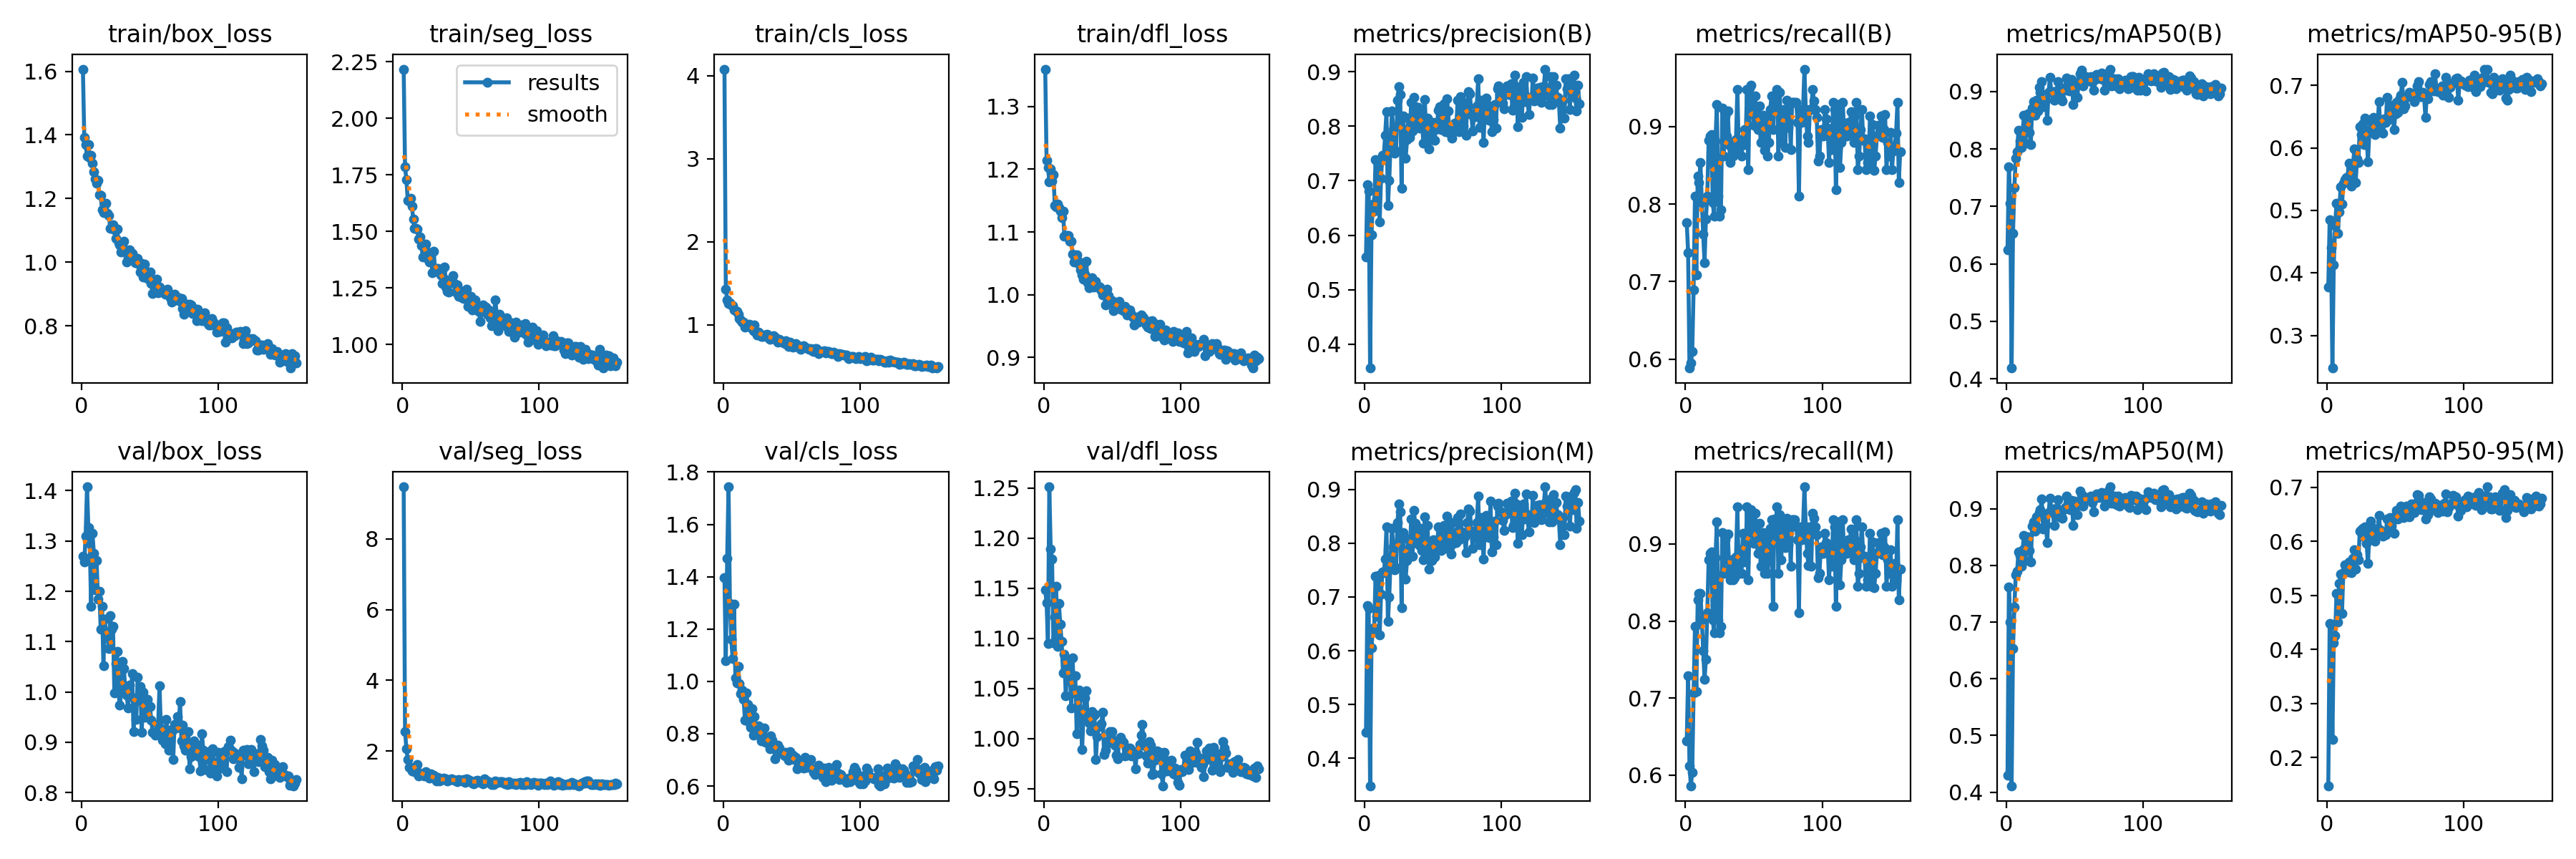


🎯 Confusion Matrix:


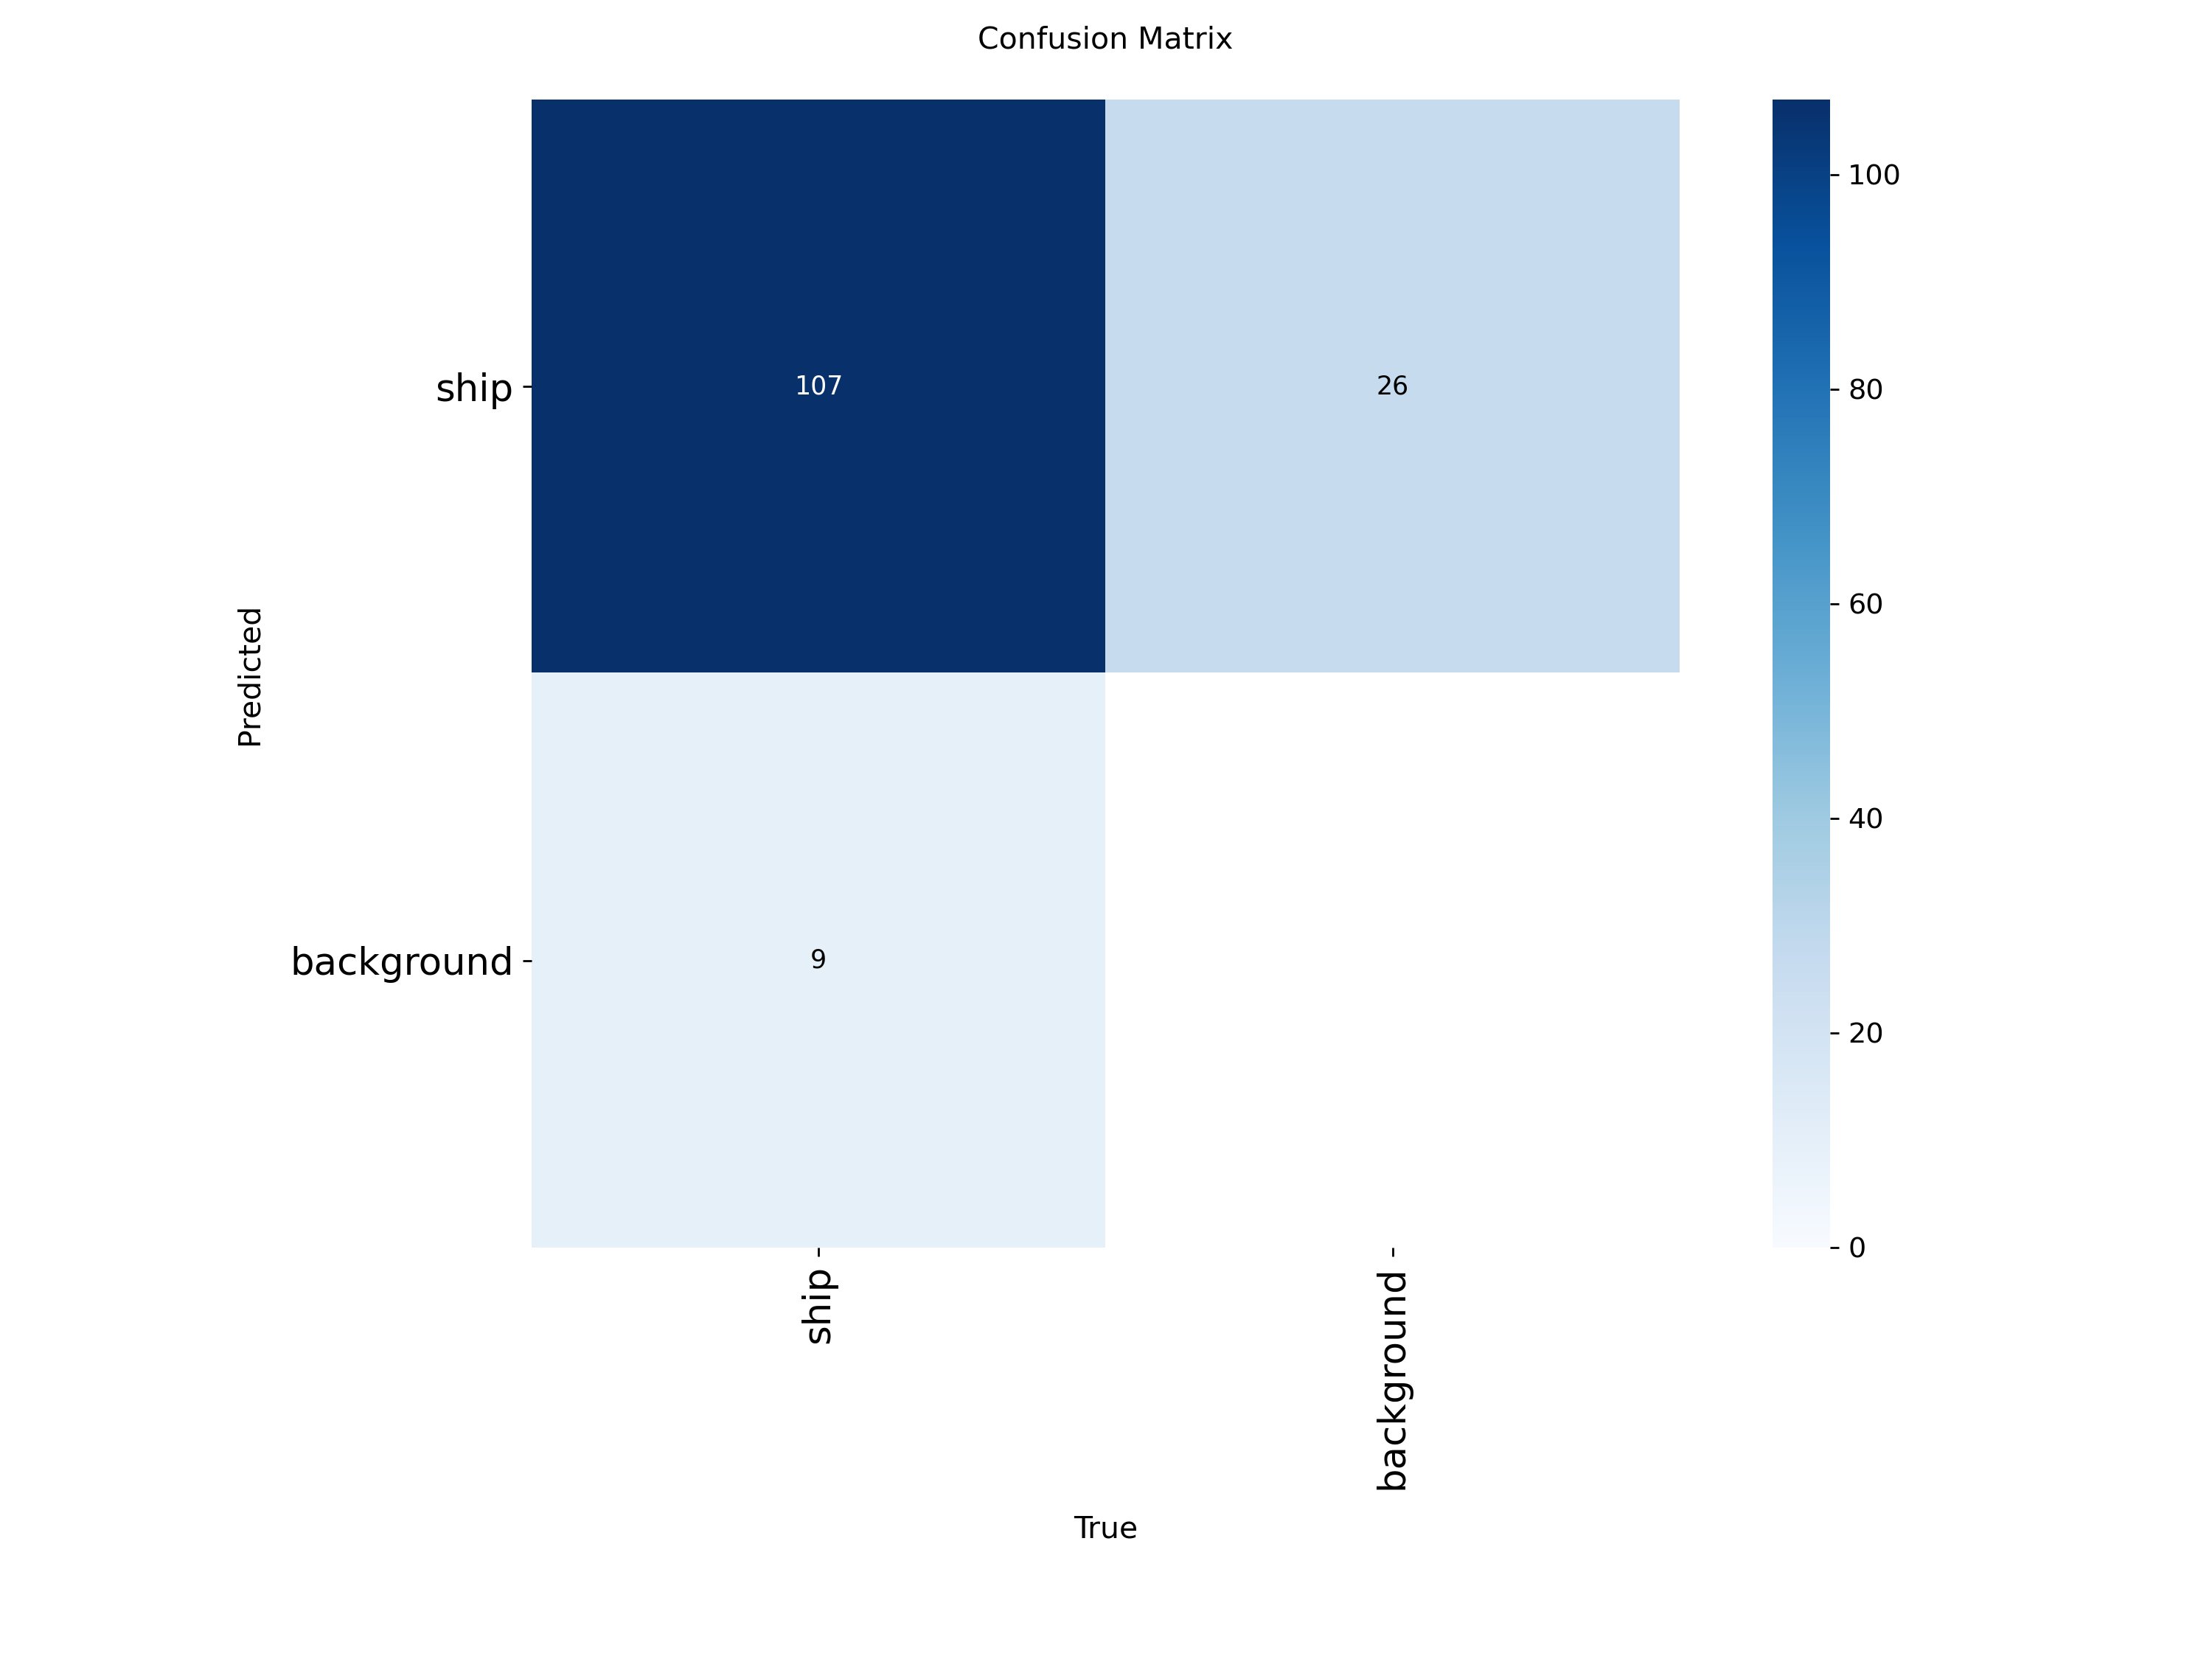


🔍 Validation Predictions:


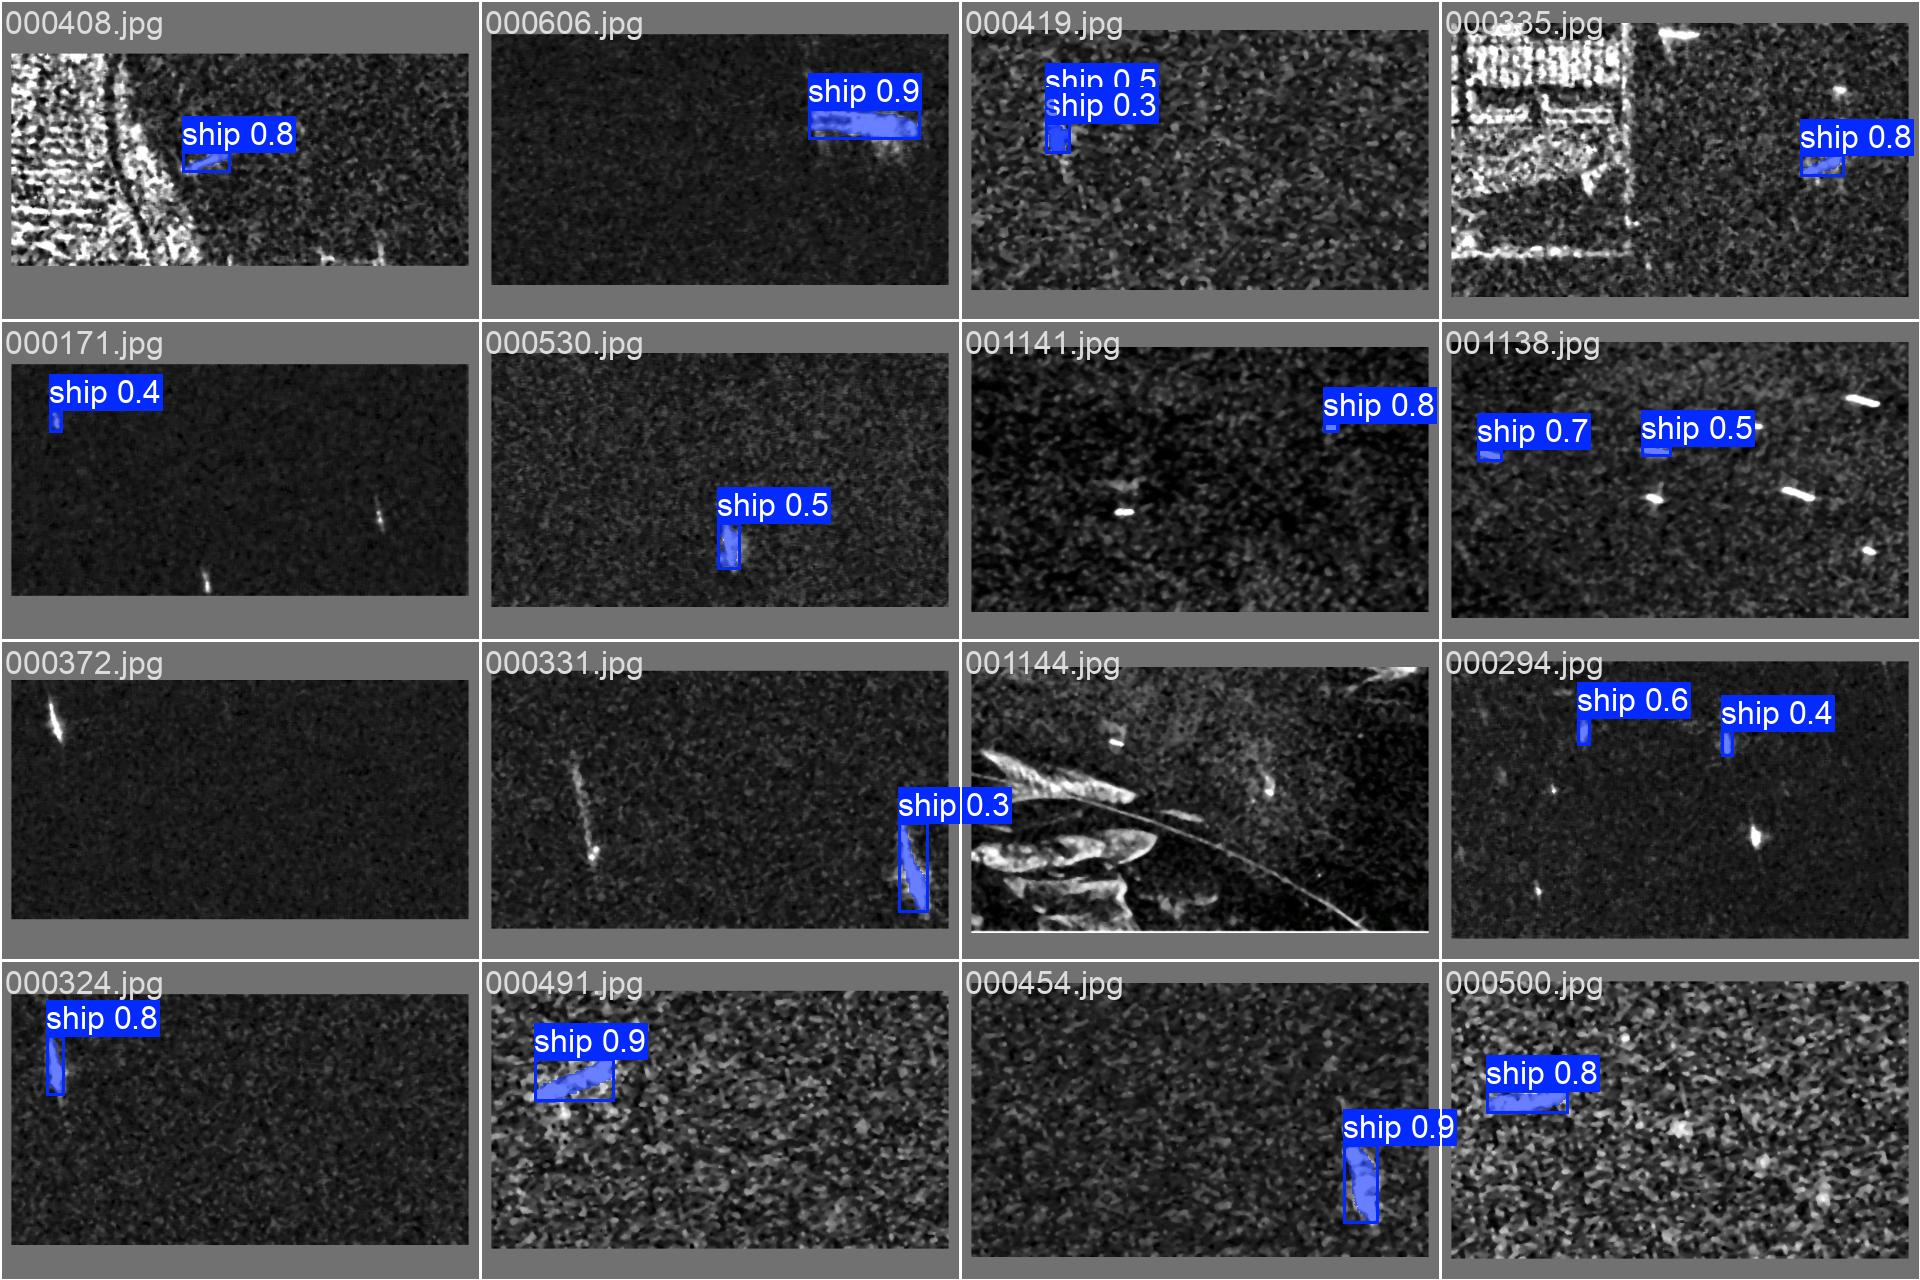

In [ ]:
# Display training plots
results_dir = f'/content/runs/segment/{SELECTED_MODEL}_ship_segmentation'

# Training curves
results_img = f'{results_dir}/results.png'
if os.path.exists(results_img):
    print("📈 Training Curves:")
    display(Image(results_img))

# Confusion matrix
confusion_matrix_img = f'{results_dir}/confusion_matrix.png'
if os.path.exists(confusion_matrix_img):
    print("\n🎯 Confusion Matrix:")
    display(Image(confusion_matrix_img))

# Validation predictions
val_batch_img = f'{results_dir}/val_batch0_pred.jpg'
if os.path.exists(val_batch_img):
    print("\n🔍 Validation Predictions:")
    display(Image(val_batch_img))

# PR curve
pr_curve_img = f'{results_dir}/PR_curve.png'
if os.path.exists(pr_curve_img):
    print("\n📊 Precision-Recall Curve:")
    display(Image(pr_curve_img))

## 🔮 Test Inference on Sample Images

🔮 Testing segmentation inference with confidence threshold = 0.25
000130.jpg - Ship 1: Confidence = 0.867
000130.jpg - Generated 1 segmentation masks
000416.jpg - Ship 1: Confidence = 0.925
000416.jpg - Ship 2: Confidence = 0.547
000416.jpg - Generated 2 segmentation masks
000779.jpg - Ship 1: Confidence = 0.839
000779.jpg - Generated 1 segmentation masks
000967.jpg - Ship 1: Confidence = 0.798
000967.jpg - Generated 1 segmentation masks


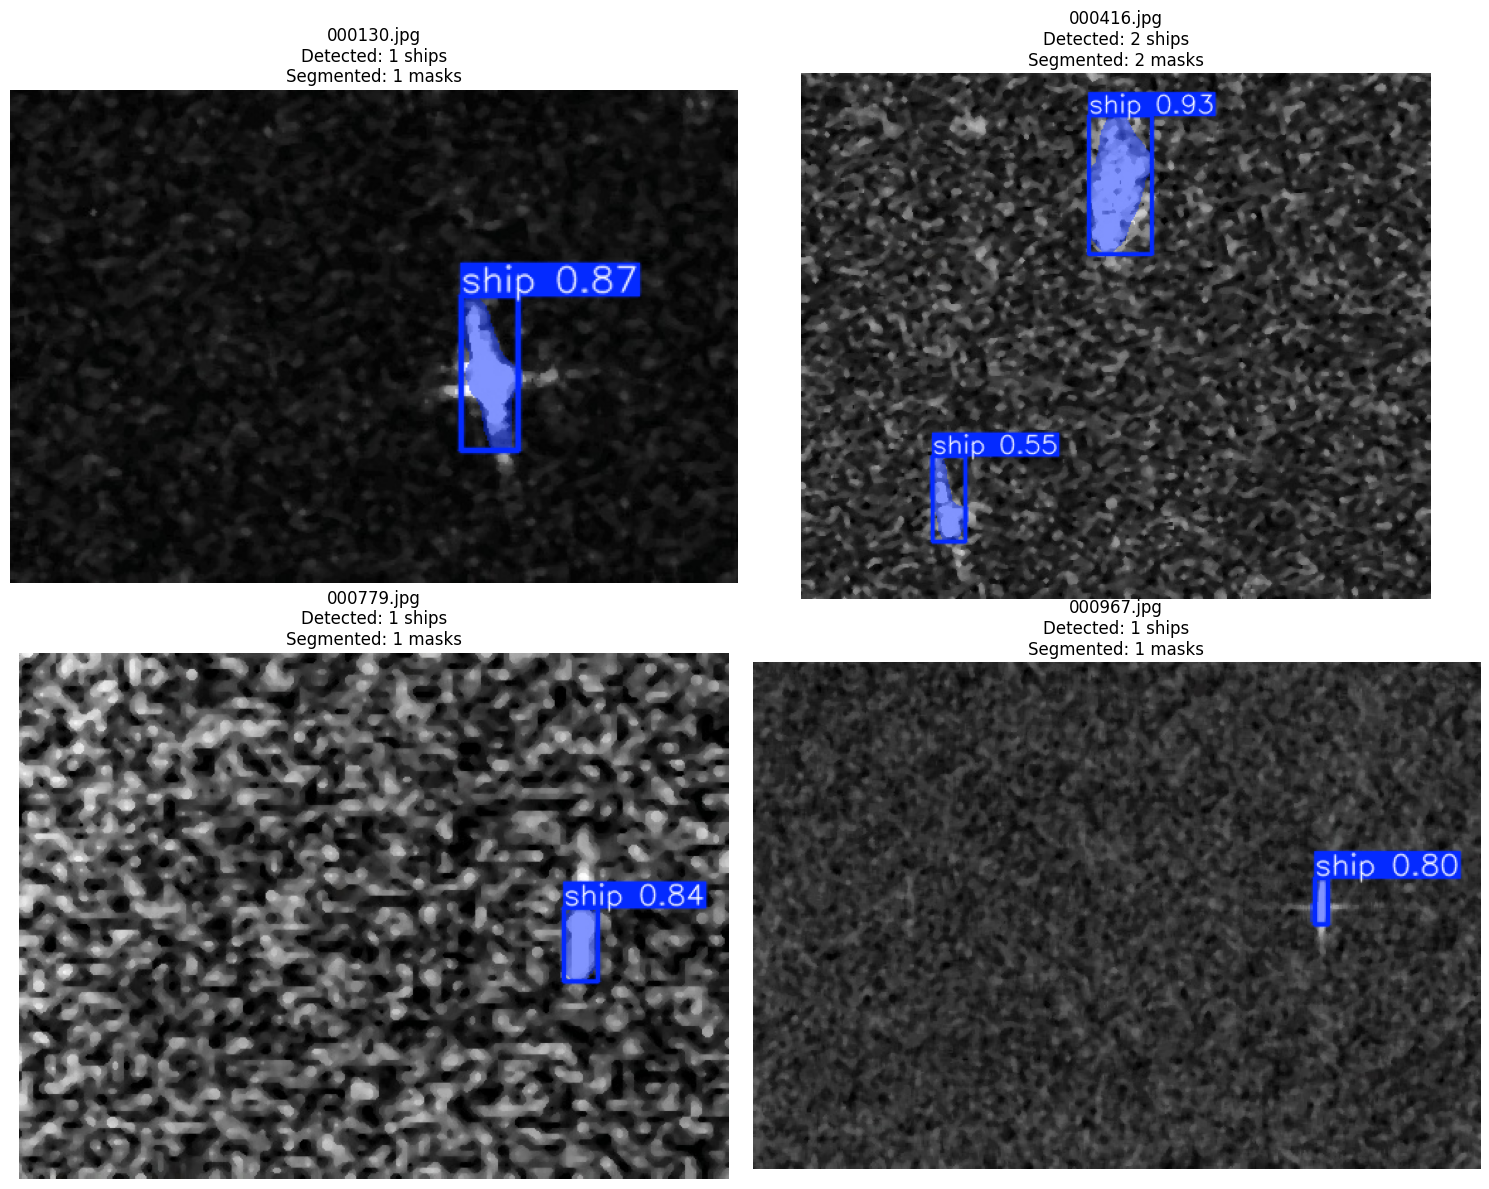


🔮 Testing with higher confidence threshold = 0.5
000130.jpg - Ship 1: Confidence = 0.867
000130.jpg - Generated 1 segmentation masks
000416.jpg - Ship 1: Confidence = 0.925
000416.jpg - Ship 2: Confidence = 0.547
000416.jpg - Generated 2 segmentation masks
000779.jpg - Ship 1: Confidence = 0.839
000779.jpg - Generated 1 segmentation masks
000967.jpg - Ship 1: Confidence = 0.798
000967.jpg - Generated 1 segmentation masks


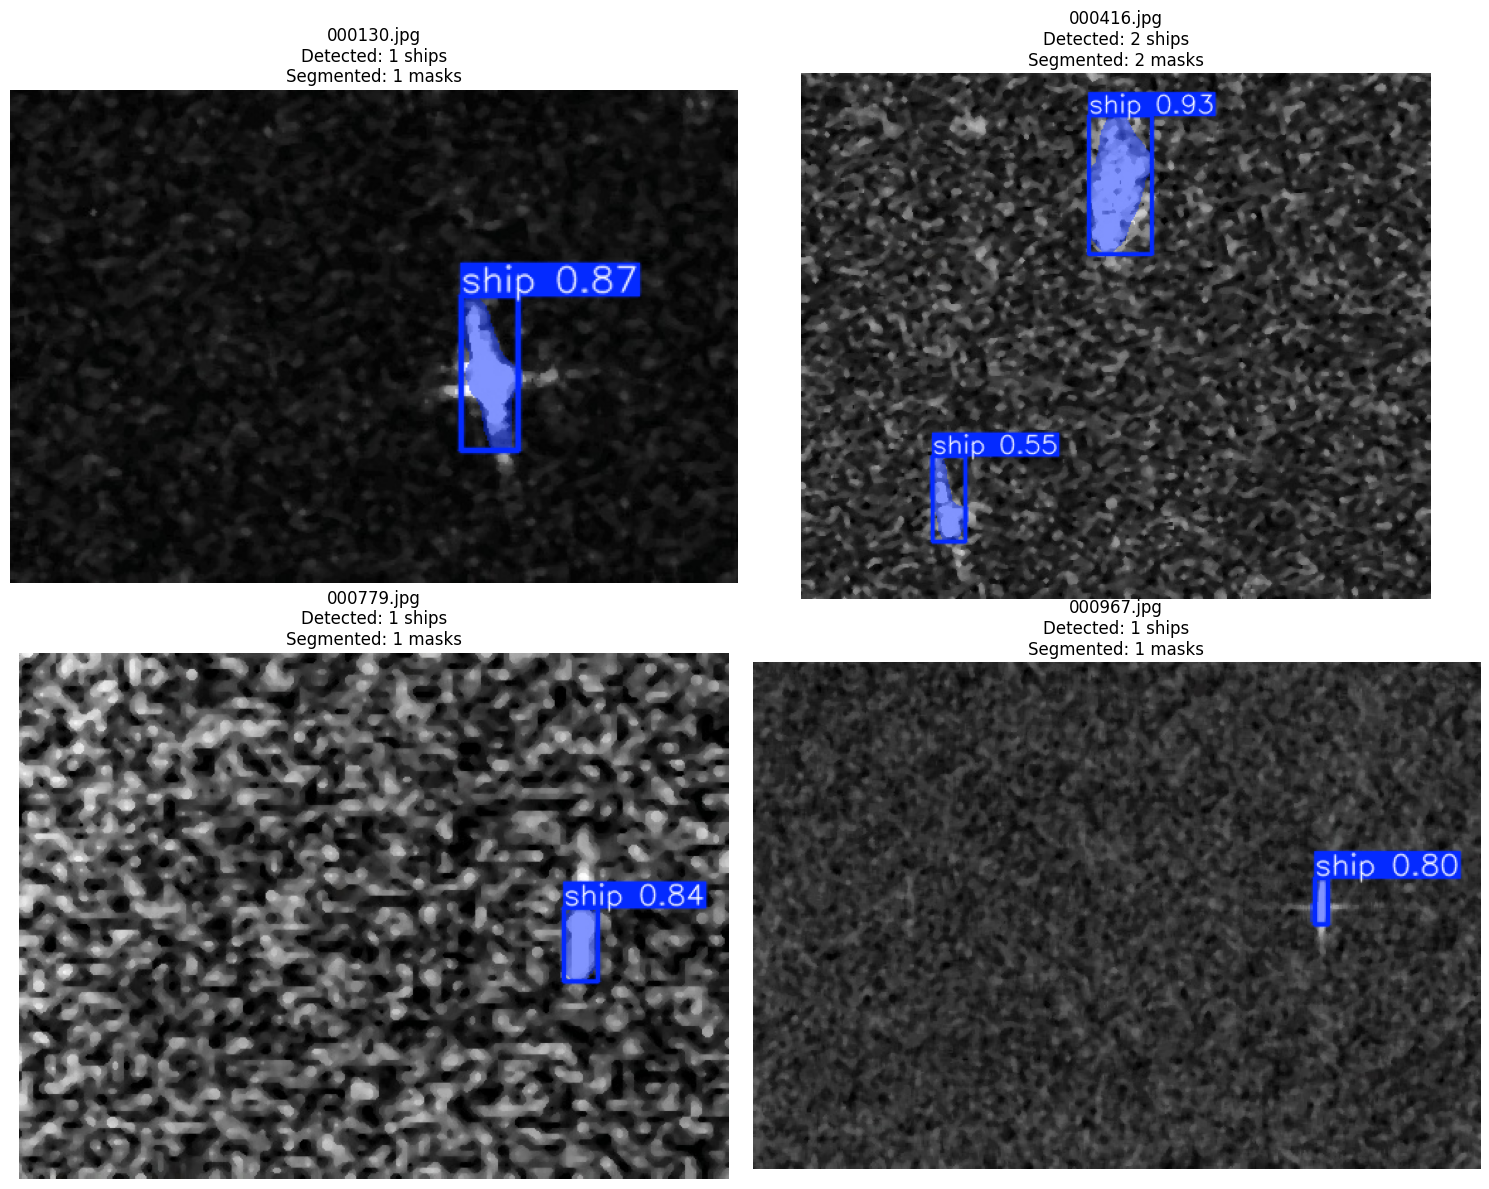

In [ ]:
# Test inference on sample images
def test_inference(model, dataset_path, split='test', num_samples=4, conf_threshold=0.25):
    images_dir = dataset_path / split / 'images'
    image_files = list(images_dir.glob('*.jpg'))[:num_samples]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, img_path in enumerate(image_files):
        if i >= num_samples:
            break

        # Run inference
        results = model(str(img_path), conf=conf_threshold, verbose=False)

        # Get result image
        result_img = results[0].plot()
        result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

        # Count detections and segments
        num_detections = len(results[0].boxes) if results[0].boxes is not None else 0
        num_segments = len(results[0].masks) if results[0].masks is not None else 0

        axes[i].imshow(result_img)
        axes[i].set_title(f"{img_path.name}\nDetected: {num_detections} ships\nSegmented: {num_segments} masks")
        axes[i].axis('off')

        # Print details
        if results[0].boxes is not None:
            for j, box in enumerate(results[0].boxes):
                conf = box.conf[0].item()
                print(f"{img_path.name} - Ship {j+1}: Confidence = {conf:.3f}")

        if results[0].masks is not None:
            print(f"{img_path.name} - Generated {len(results[0].masks)} segmentation masks")

    # Hide unused subplots
    for i in range(len(image_files), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("🔮 Testing segmentation inference with confidence threshold = 0.25")
test_inference(trained_model, dataset_path, 'test', 4, 0.25)

print("\n🔮 Testing with higher confidence threshold = 0.5")
test_inference(trained_model, dataset_path, 'test', 4, 0.5)

## 💾 Export and Download Model

In [ ]:
# Export segmentation model
print("📦 Exporting segmentation model...")

try:
    onnx_path = trained_model.export(format='onnx', imgsz=TRAINING_CONFIG['imgsz'])
    print(f"✅ ONNX model exported: {onnx_path}")
except Exception as e:
    print(f"❌ ONNX export failed: {e}")

# Create summary file
summary_file = f'/content/training_summary_{SELECTED_MODEL}.txt'
with open(summary_file, 'w') as f:
    f.write(f"YOLO Ship Segmentation Training Summary\n")
    f.write(f"======================================\n\n")
    f.write(f"Model: {SELECTED_MODEL}\n")
    f.write(f"Dataset: SSDD (SAR Ship Segmentation)\n")
    f.write(f"Total Images: {total_images}\n")
    f.write(f"Total Ships: {total_objects}\n\n")
    f.write(f"Training Configuration:\n")
    f.write(f"- Epochs: {TRAINING_CONFIG['epochs']}\n")
    f.write(f"- Batch Size: {TRAINING_CONFIG['batch_size']}\n")
    f.write(f"- Image Size: {TRAINING_CONFIG['imgsz']}\n")
    f.write(f"- Learning Rate: {TRAINING_CONFIG['lr0']}\n")
    f.write(f"- Optimizer: {TRAINING_CONFIG['optimizer']}\n\n")
    f.write(f"Results:\n")
    f.write(f"Box Detection:\n")
    f.write(f"- Box mAP50: {val_results.box.map50:.4f}\n")
    f.write(f"- Box mAP50-95: {val_results.box.map:.4f}\n")
    f.write(f"- Box Precision: {val_results.box.mp:.4f}\n")
    f.write(f"- Box Recall: {val_results.box.mr:.4f}\n")
    f.write(f"- Box F1-Score: {box_f1:.4f}\n")
    f.write(f"Segmentation:\n")
    f.write(f"- Mask mAP50: {val_results.seg.map50:.4f}\n")
    f.write(f"- Mask mAP50-95: {val_results.seg.map:.4f}\n")
    f.write(f"- Mask Precision: {val_results.seg.mp:.4f}\n")
    f.write(f"- Mask Recall: {val_results.seg.mr:.4f}\n")
    f.write(f"- Mask F1-Score: {mask_f1:.4f}\n")

print(f"\n📄 Training summary saved: {summary_file}")

# Download files
print("\n💾 Downloading files...")
files.download(best_model_path)
files.download(summary_file)

import shutil

drive_path = "/content/drive/MyDrive/YOLO_Exports"
os.makedirs(drive_path, exist_ok=True)

shutil.copy(best_model_path, drive_path)
shutil.copy(summary_file, drive_path)
if os.path.exists(results_img):
    shutil.copy(results_img, drive_path)

print(f"✅ Files saved to Google Drive at: {drive_path}")


if os.path.exists(results_img):
    files.download(results_img)

print("\n✅ Downloads complete!")
print(f"\n🎯 Model Performance Summary:")
print(f"📦 Box Detection:")
print(f"  Box mAP50: {val_results.box.map50:.1%}")
print(f"  Box Precision: {val_results.box.mp:.1%}")
print(f"  Box Recall: {val_results.box.mr:.1%}")
print(f"🎭 Segmentation:")
print(f"  Mask mAP50: {val_results.seg.map50:.1%}")
print(f"  Mask Precision: {val_results.seg.mp:.1%}")
print(f"  Mask Recall: {val_results.seg.mr:.1%}")

📦 Exporting segmentation model...
Ultralytics 8.3.216 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/segment/yolov8s-seg_ship_segmentation/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (22.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 7.0s, saved as '/content/runs/segment/yolov8s-seg_ship_segmentation/weights/best.onnx' (45.2 MB)

Export complete (8.2s)
Results saved to /content/runs/segment/yolov8s-

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads complete!

🎯 Model Performance Summary:
📦 Box Detection:
  Box mAP50: 92.0%
  Box Precision: 86.3%
  Box Recall: 84.5%
🎭 Segmentation:
  Mask mAP50: 91.7%
  Mask Precision: 86.3%
  Mask Recall: 84.5%


## 📖 Usage Instructions

### Using the Trained Segmentation Model

```python
from ultralytics import YOLO

# Load trained segmentation model
model = YOLO('path/to/your/best.pt')

# Run inference
results = model('path/to/image.jpg', conf=0.25)

# Show results with segmentation masks
results[0].show()

# Access segmentation masks
if results[0].masks is not None:
    masks = results[0].masks.data
    print(f"Found {len(masks)} segmentation masks")

# Access boxes and masks
boxes = results[0].boxes
masks = results[0].masks
```

### Performance Guidelines

**Box Detection:**
- mAP50 > 0.7: Excellent
- mAP50 > 0.5: Good
- mAP50 > 0.3: Moderate

**Segmentation:**
- Mask mAP50 > 0.6: Excellent
- Mask mAP50 > 0.4: Good
- Mask mAP50 > 0.2: Moderate

### Next Steps

1. Deploy the segmentation model
2. Fine-tune confidence thresholds
3. Try different models for better accuracy
4. Post-process masks for specific applications

---

**🎉 Your YOLO ship segmentation model is ready!**